# Realtime WR-GMM Workflow

이 노트북은 `real_time_UCC/original_forecast`에 이미 내려받은 자료를 사용해서 아래 순서로 진행합니다.

1. 모델별 raw z500 로드
2. 일자료화, 영역 자르기, CORe grid 리그리드
3. CORe climatology로 anomaly 계산
4. GMM으로 WT probability 계산
5. 월별 WT precip profile로 WRGMM 강수 앙상블 생성
6. lead month별 월평균 강수 계산
7. coeff의 clim/sd/r을 사용해 tercile 확률 계산


In [ ]:
def get_period(year, month, period):
    init_month = pd.Timestamp(year, month, 1)

    if period == 1:
        start = init_month + pd.DateOffset(days=15)
        end = init_month + pd.offsets.MonthEnd(0)
    elif period == 2:
        start = init_month + pd.DateOffset(months=1)
        end = start + pd.offsets.MonthEnd(0)
    elif period == 3:
        start = init_month + pd.DateOffset(months=2)
        end = start + pd.offsets.MonthEnd(0)
    elif period == 4:
        start = init_month + pd.DateOffset(months=3)
        end = start + pd.offsets.MonthEnd(0)
    elif period == 5:
        start = init_month + pd.DateOffset(months=1)
        end = init_month + pd.DateOffset(months=3) + pd.offsets.MonthEnd(0)

    return start, end

def make_hist_weight():
    savepath = OUTPUT_DIR / "hist.r2.1981-2010.cfsv2_native.nc"

    if savepath.exists():
        return xr.open_dataset(savepath).hist_r2.load()

    cpc_hist = xr.open_dataset(CPC_HIST_PATH).precip
    cpc_hist = cpc_hist.rename({"latitude": "lat", "longitude": "lon"})
    cpc_hist = cpc_hist.resample(time="MS").mean()

    wrgmm_hist = xr.open_dataset(WRGMM_HIST_PATH).precip_wrgmm
    cpc_hist, wrgmm_hist = xr.align(cpc_hist, wrgmm_hist, join="inner")

    hist_r2 = (xr.corr(cpc_hist, wrgmm_hist, dim="time") ** 2).rename("hist_r2")
    hist_r2.load().to_netcdf(savepath)
    print(f"Saved: {savepath}")
    return hist_r2


In [ ]:
from pathlib import Path
import argparse
import numpy as np
import pandas as pd
import xarray as xr


BASE_DIR = Path("/work05/home/jihun/real_time_CPC")
CFS_DIR = BASE_DIR / "CFSv2"
OUTPUT_DIR = BASE_DIR / "coeff"

MEMBERS = tuple(
    (day, hour) for day in (4, 5, 6) for hour in (0, 6, 12, 18)
)

CPC_PATH = BASE_DIR / "cpc.201101-202208.cfsv2_native_grid.nc"
CPC_HIST_PATH = BASE_DIR / "cpc.198101-201012.cfsv2_native_grid.nc"
WRGMM_HIST_PATH = BASE_DIR / "CORe_WRGMM_monthly_precip.1981-2010.nc"


def fourth_root(data):
    return np.sign(data) * np.abs(data) ** 0.25


def calculate_coefficients(forecast, observation):
    forecast = fourth_root(forecast)
    observation = fourth_root(observation)

    clim = forecast.groupby("time.month").mean("time")
    sd = forecast.groupby("time.month").std("time", ddof=1)
    obs_clim = observation.groupby("time.month").mean("time")
    obs_sd = observation.groupby("time.month").std("time", ddof=1)

    corr = []
    for month in clim.month.values:
        temp_fcst = forecast.where(forecast.time.dt.month == month, drop=True)
        temp_obs = observation.where(observation.time.dt.month == month, drop=True)
        temp_r = xr.corr(temp_fcst, temp_obs, dim="time")
        corr.append(temp_r.expand_dims(month=[month]))

    corr = xr.concat(corr, dim="month").clip(-0.9999, 0.9999)
    return clim, sd, corr, obs_clim, obs_sd


def save_coeff(data, path, varname, member, period, sample_count):
    data = data.rename(varname)
    data.attrs.update(
        member=member,
        period=f"P{period}",
        sample_count=sample_count,
        transformation="fourth root",
    )
    data.to_netcdf(
        path,
        encoding={varname: {"zlib": True, "complevel": 4, "dtype": "float32"}},
    )
    print(f"Saved: {path}")




In [ ]:
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--start-year", type=int, default=2012)
    parser.add_argument("--end-year", type=int, default=2021)
    parser.add_argument(
        "--members", nargs="+",
        default=[f"{day:02d}{hour:02d}" for day, hour in MEMBERS],
    )
    parser.add_argument("--allow-partial", action="store_true")
    args = parser.parse_args()

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    cpc_pr = xr.open_dataset(CPC_PATH).precip.load()
    hist_weight = make_hist_weight()

    # day/hour가 최외곽 반복문: 각 시점을 독립적으로 계산한다.
    for day, hour in MEMBERS:
        member = f"{day:02d}{hour:02d}"
        if member not in args.members:
            continue

        print(f"\n===== START {member} =====")

        CPC = {period: [] for period in range(1, 6)}
        CFSv2 = {period: [] for period in range(1, 6)}
        CFSv2_WRGMM = {period: [] for period in range(1, 6)}
        missing = []

        for year in range(args.start_year, args.end_year + 1):
            for month in range(1, 13):
                ym = f"{year}{month:02d}"
                output_time = pd.Timestamp(year, month, 1)

                cfsv2_path = (
                    CFS_DIR / f"precip_{member}" /
                    f"prate.{ym}{day:02d}{hour:02d}.nc"
                )
                wrgmm_path = (
                    CFS_DIR / f"z500_{member}" / "precip_WRGMM_CFSR" /
                    f"precip.WRGMM.{ym}.nc"
                )

                try:
                    temp_cfsv2 = xr.open_dataset(cfsv2_path).precip.load()
                    temp_wrgmm = xr.open_dataarray(wrgmm_path).load()
                except (FileNotFoundError, OSError) as error:
                    if not args.allow_partial:
                        raise
                    print(f"FILE NOT FOUND {ym} {member}: {error}")
                    missing.append([ym, str(error)])
                    continue

                for period in range(1, 6):
                    start, end = get_period(year, month, period)

                    temp_cpc = cpc_pr.sel(time=slice(start, end))
                    temp_cfs = temp_cfsv2.sel(time=slice(start, end))
                    temp_wrgmm_period = temp_wrgmm.sel(time=slice(start, end))

                    if min(
                        temp_cpc.time.size,
                        temp_cfs.time.size,
                        temp_wrgmm_period.time.size,
                    ) == 0:
                        print(f"NO DATA {ym} {member} P{period}")
                        continue

                    cpc_mean = temp_cpc.mean("time")
                    cfsv2_mean = temp_cfs.mean("time")
                    wrgmm_mean = temp_wrgmm_period.mean("time")

                    cfsv2_mean = xr.where(cpc_mean.isnull(), np.nan, cfsv2_mean)
                    wrgmm_mean = xr.where(cpc_mean.isnull(), np.nan, wrgmm_mean)

                    CPC[period].append(cpc_mean.expand_dims(time=[output_time]))
                    CFSv2[period].append(cfsv2_mean.expand_dims(time=[output_time]))
                    CFSv2_WRGMM[period].append(
                        wrgmm_mean.expand_dims(time=[output_time])
                    )

        member_output = OUTPUT_DIR / member
        member_output.mkdir(parents=True, exist_ok=True)

        for period in range(1, 6):
            if len(CFSv2[period]) == 0:
                print(f"NO VALID SAMPLE {member} P{period}")
                continue

            cpc = xr.concat(CPC[period], dim="time")
            cfsv2 = xr.concat(CFSv2[period], dim="time")
            wrgmm = xr.concat(CFSv2_WRGMM[period], dim="time")

            exwrgmm = cfsv2 * (1 - hist_weight) + wrgmm * hist_weight
            coeff = calculate_coefficients(exwrgmm, cpc)
            clim, sd, corr, obs_clim, obs_sd = coeff

            sample_count = len(CFSv2[period])
            prefix = member_output / f"CFSv2.P{period}.exWRGMM"

            save_coeff(clim, Path(f"{prefix}.clim.120mon.nc"),
                       "clim", member, period, sample_count)
            save_coeff(sd, Path(f"{prefix}.sd.120mon.nc"),
                       "sd", member, period, sample_count)
            save_coeff(corr, Path(f"{prefix}.r.120mon.nc"),
                       "r", member, period, sample_count)
            save_coeff(obs_clim, member_output / f"CPC.P{period}.pr.clim.120mon.nc",
                       "clim", member, period, sample_count)
            save_coeff(obs_sd, member_output / f"CPC.P{period}.pr.sd.120mon.nc",
                       "sd", member, period, sample_count)

        if missing:
            pd.DataFrame(missing, columns=["initialization_month", "reason"]).to_csv(
                member_output / "missing_files.csv", index=False
            )

        print(f"===== END {member} =====")


if __name__ == "__main__":
    main()


usage: ipykernel_launcher.py [-h] [--start-year START_YEAR]
                             [--end-year END_YEAR]
                             [--months MONTHS [MONTHS ...]]
                             [--members MEMBERS [MEMBERS ...]]
                             [--output-dir OUTPUT_DIR] [--allow-partial]
ipykernel_launcher.py: error: unrecognized arguments: --f=/run/user/1102/jupyter/runtime/kernel-v3e6c15679d189622690f48e9092eaea0a448c3737.json


SystemExit: 2

/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3377: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [18]:
CFSv2_WRGMM[1]

<xarray.DataArray (time: 1, ensemble: 2, lat: 30, lon: 75)>
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]])
Coordinates:
  * time      (time) datetime64[ns] 2012-01-01
  * ensemble  (ensemble) <U4 '0400' '0406'
  * lat       (lat) float64 20.5 21.5 22.5 23.5 24.5 ... 46.5 47.5 48.5 49.5
  * lon       (lon) float64 230.5 231.5 232.5 233.5 ... 301.5 302.5 303.5 304.5

In [ ]:
datapath = "/work05/home/jihun/seasonal_forecast"

for ldm in range(1, 5):
    globals()["CPC_"+str(ldm)] = []
    globals()["CFSv2_"+str(ldm)] = []
    globals()["CFSv2_WRGMM_"+str(ldm)] = []

    for year in range(2011, 2023):
        for month in range(1,13):
            try:
                tmonth = month + ldm - 1
                tyear = year
                if tmonth > 12:
                    tmonth = tmonth - 12
                    tyear = tyear + 1
                temp = xr.open_dataset(datapath+"/CPC_2011_2022/cpc."+str(tyear)+str(tmonth).zfill(2)+".nc").precip
                times = temp.time

                globals()["CPC_"+str(ldm)].append(temp.mean("time").expand_dims(time=[times[0].values]))
                
            # load cfsv2 data
                temp_cfsv2 = xr.open_dataset(datapath+"/CFSv2/precip/prate."+str(year)+str(month).zfill(2)+"01.nc").precip
                temp_cfsv2 = temp_cfsv2.sel(time = times)
                temp_cfsv2_mask = xr.where(temp.isnull(), float('nan'), temp_cfsv2)
                globals()["CFSv2_"+str(ldm)].append(temp_cfsv2_mask.mean("time").expand_dims(time=[times[0].values]))     

            # load cfsv2 wrmm data
                temp_cfsv2_wrgmm = xr.open_dataarray(datapath+"/CFSv2/precip_WRGMM_CFSR/precip_WRGMM_"+str(year)+str(month).zfill(2)+".nc")
                temp_cfsv2_wrgmm = temp_cfsv2_wrgmm.sel(time = times)
                globals()["CFSv2_WRGMM_"+str(ldm)].append(temp_cfsv2_wrgmm.mean("time").expand_dims(time=[times[0].values]))

            except FileNotFoundError:
                pass
                # print("file not found:", year, month)
                
    globals()["CPC_"+str(ldm)] = xr.concat(globals()["CPC_"+str(ldm)], dim = "time")
    globals()["CFSv2_"+str(ldm)] = xr.concat(globals()["CFSv2_"+str(ldm)], dim = "time")
    globals()["CFSv2_WRGMM_"+str(ldm)] = xr.concat(globals()["CFSv2_WRGMM_"+str(ldm)], dim = "time")

In [1]:
from pathlib import Path
import csv
import pickle
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import scipy.stats
import xarray as xr

import multiprocessing as mp

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.colors import ListedColormap, BoundaryNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader
from shapely.geometry import box

In [2]:
GRAVITY = 9.80665
N_WT = 5
N_LEADS = 4

BASE_DIR = Path('/work05/home/jihun/real_time_CPC')
RAW_DIR = BASE_DIR / 'original_forecast'
COEFF_DIR = BASE_DIR / 'coeff'
PROFILE_DIR = BASE_DIR / 'precip_profile'
OUTPUT_DIR = BASE_DIR / 'rt_output'

GMM_PATH = BASE_DIR / 'gmm_CORe.sav'
HIST_R_PATH = COEFF_DIR / 'hist.r.1981-2010.nc'
CLIM_PATH = COEFF_DIR / 'CORe.daily.z500.clim.1981-2010.nc'
OBS_CLIM_PATH = COEFF_DIR / 'CPC.monthly.pr.clim.1981-2010.nc'
OBS_SD_PATH = COEFF_DIR / 'CPC.monthly.pr.sd.1981-2010.nc'

MODEL_NAMES = ['ECMWF',  'NCEP']
NCEP_MEMBER_LAYOUT = [
    ('same_day', 0),
    ('pre1_day', 2),
    ('pre1_day', 1),
    ('pre1_day', 0),
    ('pre2_day', 2),
    ('pre2_day', 1),
    ('pre2_day', 0),
]

now = datetime.now()
year = now.year
month = now.month

year = 2026
month = 4

init_date = f"{year}{month:02d}01"
init_date

GRIB_VAR_CANDIDATES = {
    'z500': ('z', 'gh', 'var129'),
    'tp': ('tp', 'var228'),
}
GRIB_LEAD_STEPS = {'z500': 260, 'tp': 130}
GRIB_MEMBER_LIMITS = {'ECMWF': 25}


In [3]:
def open_dataarray(path, var_name=None):
    ds = xr.open_dataset(path)
    if var_name and var_name in ds.data_vars:
        return ds[var_name]
    return ds[next(iter(ds.data_vars))]

def load_gmm():
    with open(GMM_PATH, 'rb') as handle:
        return pickle.load(handle)

def load_core_climatology():
    return open_dataarray(CLIM_PATH, 'z500').squeeze('plev', drop=True)

def load_hist_r_weight():
    return open_dataarray(HIST_R_PATH)

def load_model_coeff(model, lead_month, kind):
    path = COEFF_DIR / f'{model}.{lead_month}.exWRGMM.{kind}.120mon.nc'
    da = open_dataarray(path)
    if 'ensemble' in da.dims and 'ensemble' not in da.coords:
        da = da.assign_coords(ensemble=np.arange(da.sizes['ensemble']))
    return da

def load_precip_profile(month, wt):
    path = PROFILE_DIR / f'Precip{month:02d}WT{wt}.nc'
    return open_dataarray(path, 'precip')

def get_target_month_starts(init_date, n_leads=N_LEADS):
    return pd.date_range(start=pd.Timestamp(init_date), periods=n_leads, freq='MS')

def fourth_root(pr):
    return np.sign(pr) * np.abs(pr) ** 0.25

def to_minus180(lon):
    return ((lon + 180) % 360) - 180

def open_grib_dataarray(path, field):
    if not path.exists():
        raise FileNotFoundError(path)

    try:
        ds = xr.open_dataset(
            path,
            engine='cfgrib',
            backend_kwargs={
                'indexpath': '',
                'errors': 'ignore',
            },
        )
    except ValueError as exc:
        if 'cfgrib' in str(exc):
            raise ImportError(
                'Reading GRIB directly requires cfgrib/eccodes in this Python environment.'
            ) from exc
        raise

    for candidate in GRIB_VAR_CANDIDATES[field]:
        if candidate in ds.data_vars:
            var_name = candidate
            break
    else:
        var_name = next(iter(ds.data_vars))
    return ds[var_name]

In [4]:
def normalize_grib_dims(da, model):
    if model == "NCEP":
        rename_map = {
            'latitude': 'lat',
            'longitude': 'lon',
            'step': 'lead',
            'time': 'ensemble',
            'realization': 'ensemble',
        }
    elif model == "ECMWF":
        rename_map = {
            'latitude': 'lat',
            'longitude': 'lon',
            'step': 'lead',
            'number': 'ensemble',
            'realization': 'ensemble',
        }
    da = da.rename({old: new for old, new in rename_map.items() if old in da.dims or old in da.coords})
    for dim in ['surface', 'isobaricInhPa', 'isobaricInPa', 'heightAboveGround']:
        if dim in da.dims and da.sizes[dim] == 1:
            da = da.squeeze(dim, drop=True)
    return da

def grib_to_ensemble(da, model, field, member_indices=None):
    da = normalize_grib_dims(da, model).squeeze(drop=True)

    if 'ensemble' in da.dims and 'lead' in da.dims:
        if member_indices is not None:
            da = da.isel(ensemble=list(member_indices))

        if 'valid_time' in da.coords:
            valid_time = da['valid_time'].isel(ensemble=0).values if 'ensemble' in da['valid_time'].dims else da['valid_time'].values
            da = da.assign_coords(time=('lead', pd.to_datetime(valid_time)))
        elif 'time' not in da.coords:
            raise ValueError('GRIB has ensemble/lead dimensions but no time or valid_time coordinate')

        da = da.swap_dims({'lead': 'time'}) if 'lead' in da.dims else da
        if 'lead' in da.coords:
            da = da.drop_vars('lead')
        return da

    if 'valid_time' in da.coords and 'time' not in da.dims:
        da = da.assign_coords(time=pd.to_datetime(da['valid_time'].values))

    lead_steps = GRIB_LEAD_STEPS[field]
    total_members = da.sizes['time'] // lead_steps
    if da.sizes['time'] % lead_steps:
        raise ValueError(f'{field} GRIB time axis is not divisible by {lead_steps}: {da.sizes["time"]}')

    if member_indices is None:
        member_indices = range(total_members)

    members = []
    for ens in member_indices:
        if ens >= total_members:
            raise IndexError(f'Requested member {ens}, but {da.name} has only {total_members} members')
        start = ens * lead_steps
        stop = start + lead_steps
        member = da.isel(time=slice(start, stop)).copy()
        members.append(member.expand_dims(ensemble=[int(ens)]))
    return xr.concat(members, dim='ensemble')

def prepare_z500_daily_grib(da, init_date):
    da = da.squeeze(drop=True)
    da = da.assign_coords(lon=to_minus180(da.lon)).sortby('lon').sortby('lat')
    da = da.sel(lat=slice(-5, 65), lon=slice(-150, -50))
    da = da.resample(time='1D').mean()
    da = da / GRAVITY
    start = pd.Timestamp(init_date)
    end = start + pd.Timedelta(days=130 - 1)
    da = da.sel(time=slice(start, end))
    da.name = 'z500'
    return da

def load_model_z500(model, init_date):
    if model in ['ECMWF']:
        path = RAW_DIR / init_date / 'z500' / f'{model}_{init_date}.grb2'
        member_limit = GRIB_MEMBER_LIMITS.get(model)
        member_indices = None if member_limit is None else range(member_limit)
        da = open_grib_dataarray(path, 'z500')
        z500 = grib_to_ensemble(da, model, 'z500', member_indices=member_indices)
        return prepare_z500_daily_grib(z500, init_date) 
    if model == 'NCEP':
        init_ts = pd.Timestamp(init_date)
        same_path = RAW_DIR / init_date / 'z500' / f"NCEP_{init_ts.strftime('%Y%m%d')}.grb2"
        pre1_path = RAW_DIR / init_date / 'z500' / f"NCEP_{(init_ts - pd.Timedelta(days=1)).strftime('%Y%m%d')}.grb2"
        pre2_path = RAW_DIR / init_date / 'z500' / f"NCEP_{(init_ts - pd.Timedelta(days=2)).strftime('%Y%m%d')}.grb2"
        sources = {
            'same_day': open_grib_dataarray(same_path, 'z500'),
            'pre1_day': open_grib_dataarray(pre1_path, 'z500'),
            'pre2_day': open_grib_dataarray(pre2_path, 'z500'),
        }
        
        members = []
        for member_id, (which_day, ref_idx) in enumerate(NCEP_MEMBER_LAYOUT):
            raw = grib_to_ensemble(sources[which_day], model, 'z500', member_indices=[ref_idx]).isel(ensemble=0)
            daily = prepare_z500_daily_grib(raw, init_date)
            members.append(daily.expand_dims(ensemble=[member_id]))
        return xr.concat(members, dim='ensemble')
    raise ValueError(model)

def accumulated_to_daily_precip(da):
    first = da.isel(time=0)
    diffed = da.diff('time')
    daily = xr.concat([first.expand_dims(time=[da.time.values[0]]), diffed], dim='time')
    daily = xr.where(daily < 0, 0, daily)
    daily.name = 'precip'
    return daily

def prepare_tp_daily_grib(da, init_date):
    da = da.squeeze(drop=True)
    da = da.assign_coords(time=pd.to_datetime(da.time.values).normalize() - pd.Timedelta(days=1))
    da = da.sortby('lon').sortby('lat')
    da = da.sel(lat=slice(19, 51), lon=slice(228, 307))
    da = da * 1000.0
    da = accumulated_to_daily_precip(da)
    start = pd.Timestamp(init_date)
    end = start + pd.Timedelta(days=130 - 1)
    da = da.sel(time=slice(start, end))
    da.name = 'precip'
    return da

def load_model_tp(model, init_date):
    if model in ['ECMWF']:
        path = RAW_DIR / init_date / 'tp' / f'{model}_{init_date}.grb2'
        member_limit = GRIB_MEMBER_LIMITS.get(model)
        member_indices = None if member_limit is None else range(member_limit)
        da = open_grib_dataarray(path, 'tp')
        tp = grib_to_ensemble(da, model, 'tp', member_indices=member_indices)
        return prepare_tp_daily_grib(tp, init_date)
    if model == 'NCEP':
        init_ts = pd.Timestamp(init_date)
        same_path = RAW_DIR / init_date / 'tp' / f"NCEP_{init_ts.strftime('%Y%m%d')}.grb2"
        pre1_path = RAW_DIR / init_date / 'tp' / f"NCEP_{(init_ts - pd.Timedelta(days=1)).strftime('%Y%m%d')}.grb2"
        pre2_path = RAW_DIR / init_date / 'tp' / f"NCEP_{(init_ts - pd.Timedelta(days=2)).strftime('%Y%m%d')}.grb2"
        sources = {
            'same_day': open_grib_dataarray(same_path, 'tp'),
            'pre1_day': open_grib_dataarray(pre1_path, 'tp'),
            'pre2_day': open_grib_dataarray(pre2_path, 'tp'),
        }
        members = []
        for member_id, (which_day, ref_idx) in enumerate(NCEP_MEMBER_LAYOUT):
            raw = grib_to_ensemble(sources[which_day], model,'tp', member_indices=[ref_idx]).isel(ensemble=0)
            daily = prepare_tp_daily_grib(raw, init_date)
            members.append(daily.expand_dims(ensemble=[member_id]))
        return xr.concat(members, dim='ensemble')
    raise ValueError(model)

def regrid_to_core_grid(z500_daily, core_clim):
    z500_daily = z500_daily.interp(lon=core_clim.longitude, lat=core_clim.latitude, method='linear')
    drop_coords = [name for name in ['longitude', 'latitude'] if name in z500_daily.coords]
    if drop_coords:
        z500_daily = z500_daily.drop_vars(drop_coords)
    z500_daily = z500_daily.rename(lon='longitude', lat='latitude')
    return z500_daily.transpose('ensemble', 'time', 'latitude', 'longitude')

def regrid_tp_to_obs_grid(tp_daily, obs_grid):
    tp_daily = tp_daily.interp(lon=obs_grid.lon, lat=obs_grid.lat, method='linear')
    return tp_daily.transpose('ensemble', 'time', 'lat', 'lon')

def make_daily_anomaly(z500_daily_rg, core_clim):
    day_index = z500_daily_rg.time.dt.dayofyear.values.astype(int) - 1
    clim_match = core_clim.isel(time=day_index).assign_coords(time=z500_daily_rg.time.values)
    anomaly = z500_daily_rg - clim_match
    anomaly.name = 'z500_anomaly'
    return anomaly

def predict_probabilities(z500_anomaly, gmm):
    data_r = z500_anomaly.values
    data_r = np.nan_to_num(data_r, nan=0.0)
    ne, nt, ny, nx = data_r.shape
    data_1 = data_r.reshape(ne, nt, ny * nx, order='F')
    data_f = data_1.reshape(ne * nt, ny * nx, order='C')
    labels = gmm.predict_proba(data_f).reshape(ne, nt, N_WT)
    return xr.DataArray(
        labels,
        coords={'ensemble': z500_anomaly.ensemble.values, 'time': z500_anomaly.time.values, 'wt': np.arange(1, N_WT + 1)},
        dims=('ensemble', 'time', 'wt'),
        name='wt_probability',
    )

def build_wrgmm_precip(wt_probability):
    members = []
    for ens in wt_probability.ensemble.values:
        ens_prob = wt_probability.sel(ensemble=ens)
        daily_fields = []
        for current_time in ens_prob.time.values:
            ts = pd.Timestamp(current_time)
            profile_stack = xr.concat(
                [load_precip_profile(ts.month, wt).expand_dims(wt=[wt]) for wt in range(1, N_WT + 1)],
                dim='wt'
            ).transpose('wt', 'lat', 'lon')
            field = xr.dot(ens_prob.sel(time=current_time), profile_stack, dims='wt')
            daily_fields.append(field.expand_dims(time=[current_time]))
        member = xr.concat(daily_fields, dim='time').expand_dims(ensemble=[int(ens)])
        members.append(member)
    out = xr.concat(members, dim='ensemble').transpose('ensemble', 'time', 'lat', 'lon')
    out.name = 'precip_wrgmm'
    return out

def aggregate_lead_months(daily_precip, init_date, n_leads=N_LEADS):
    monthly = daily_precip.resample(time='MS').mean()
    monthly = monthly.sel(time=get_target_month_starts(init_date, n_leads=n_leads))
    monthly.name = 'precip_wrgmm_monthly'
    return monthly

def build_blended_monthly_precip(raw_monthly, wrgmm_monthly, hist_r):
    wrgmm_r = hist_r ** 2
    nwp_r = 1 - wrgmm_r
    blended = raw_monthly * nwp_r + wrgmm_monthly * wrgmm_r
    blended.name = 'precip_blended_monthly'
    return blended

def compute_tercile_probabilities(monthly_precip, model):
    zthr = scipy.stats.norm.ppf([1 / 3, 2 / 3])
    categories = ['below', 'normal', 'above']
    lead_probs = []

    for lead_idx, valid_time in enumerate(monthly_precip.time.values, start=1):
        month_number = pd.Timestamp(valid_time).month
        clim = load_model_coeff(model, lead_idx, 'clim').sel(month=month_number)
        sd = load_model_coeff(model, lead_idx, 'sd').sel(month=month_number).clip(min=1e-6)
        corr = load_model_coeff(model, lead_idx, 'r').sel(month=month_number).clip(min=-0.9999, max=0.9999)

        forecast = fourth_root(monthly_precip.sel(time=valid_time))
        if model == 'NCEP':forecast = forecast.assign_coords(ensemble=np.arange(len(forecast.ensemble)))
        zf = (forecast - clim) / sd
        spread = xr.apply_ufunc(lambda x: np.sqrt(np.maximum(1 - x**2, 1e-6)), corr)

        poe = 1 - scipy.stats.norm.cdf(
            zthr[np.newaxis, np.newaxis, np.newaxis, :],
            loc=zf.values[..., np.newaxis],
            scale=spread.values[..., np.newaxis],
        )
        prob_arr = np.stack([1 - poe[..., 0], poe[..., 0] - poe[..., 1], poe[..., 1]], axis=1)

        da = xr.DataArray(
            prob_arr,
            coords={
                'ensemble': forecast.ensemble.values,
                'category': categories,
                'lat': forecast.lat.values,
                'lon': forecast.lon.values,
            },
            dims=('ensemble', 'category', 'lat', 'lon'),
            name='tercile_probability_member',
        )
        da = da.expand_dims(lead_month=[lead_idx])
        da = da.assign_coords(target_time=('lead_month', [np.datetime64(valid_time)]))
        lead_probs.append(da)

    member_prob = xr.concat(lead_probs, dim='lead_month')
    mean_prob = member_prob.mean(dim='ensemble').rename('tercile_probability')
    return member_prob, mean_prob

def run_model(model, init_date, save=True):
    out_dir = OUTPUT_DIR / init_date / model
    out_dir.mkdir(parents=True, exist_ok=True)

    z500_daily = load_model_z500(model, init_date)
    z500_regrid = regrid_to_core_grid(z500_daily, core_clim)
    z500_anomaly = make_daily_anomaly(z500_regrid, core_clim)
    print('Done: z500 process')
    wt_probability = predict_probabilities(z500_anomaly, gmm)
    precip_wrgmm = build_wrgmm_precip(wt_probability)
    monthly_precip = aggregate_lead_months(precip_wrgmm, init_date)
    print('Done: WRGMM precip process')
    raw_tp_daily = load_model_tp(model, init_date)
    raw_tp_regrid = regrid_tp_to_obs_grid(raw_tp_daily, obs_grid)
    raw_tp_monthly = aggregate_lead_months(raw_tp_regrid, init_date)
    print('Done: raw precip process')
    blended_monthly = build_blended_monthly_precip(raw_tp_monthly, monthly_precip, hist_r)
    blended_member, blended_mean = compute_tercile_probabilities(blended_monthly, model)
    
    outputs = {
        'wt_probability': wt_probability,
        'wrgmm_precip': monthly_precip,
        'raw_precip': raw_tp_monthly,
        'exwrgmm_precip': blended_monthly,
        'tercile_member': blended_member,
        'tercile_mean': blended_mean,
    }

    # if save:
    #     wt_probability.to_netcdf(out_dir / f'{model}_{init_date}_wt_probability.nc')
    #     monthly_precip.to_netcdf(out_dir / f'{model}_{init_date}_precip_wrgmm_monthly.nc')
    #     raw_tp_monthly.to_netcdf(out_dir / f'{model}_{init_date}_precip_raw_monthly.nc')
    #     blended_monthly.to_netcdf(out_dir / f'{model}_{init_date}_precip_exwrgmm_monthly.nc')
    #     blended_member.to_netcdf(out_dir / f'{model}_{init_date}_tercile_probability_member.nc')
    #     blended_mean.to_netcdf(out_dir / f'{model}_{init_date}_tercile_probability_mean.nc')

    return outputs

core_clim = load_core_climatology()
hist_r = load_hist_r_weight()
obs_grid = open_dataarray(OBS_CLIM_PATH, 'precip')
gmm = load_gmm()

results = {}
for model in MODEL_NAMES:
    print(f'Processing {model} for {init_date}')
    results[model] = run_model(model, init_date, save=True)
    print(f'Done: {model} process')

    

Processing ECMWF for 20260401


/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")
/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. 

Done: z500 process
Done: WRGMM precip process


/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")
/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. 

Done: raw precip process
Done: ECMWF process
Processing NCEP for 20260401


/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")
/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. 

Done: z500 process
Done: WRGMM precip process


/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")
/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/opt/anaconda3/lib/python3.9/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. 

Done: raw precip process
Done: NCEP process


In [5]:
def build_outlook_masks(prob_da, equal_chance_threshold=0.40):
    prob_da = prob_da.transpose('category', 'lat', 'lon')
    valid_mask = prob_da.notnull().any('category')
    prob_filled = prob_da.fillna(-999.0)
    max_prob = xr.where(valid_mask, prob_da.max('category', skipna=True), np.nan)
    dom_idx = prob_filled.argmax('category')
    category_names = prob_da.category.values
    dominant = xr.DataArray(
        np.asarray(category_names)[dom_idx.values],
        coords={'lat': prob_da.lat, 'lon': prob_da.lon},
        dims=('lat', 'lon')
    )
    dominant = xr.where(valid_mask, dominant, 'ec')
    ec_mask = (~valid_mask) | (max_prob < equal_chance_threshold)
    masks = {
        'above': xr.where((dominant == 'above') & (~ec_mask), max_prob, np.nan),
        'normal': xr.where((dominant == 'normal') & (~ec_mask), max_prob, np.nan),
        'below': xr.where((dominant == 'below') & (~ec_mask), max_prob, np.nan),
        'ec': xr.where(ec_mask, 1.0, np.nan),
    }
    return masks, dominant, max_prob

def valid_label_from_plot_da(prob_da):
    valid_time = pd.Timestamp(prob_da.target_time.values)
    return valid_time.strftime('%B %Y')

def add_category_label(ax, mask, text):
    valid = mask.where(~np.isnan(mask), drop=True)
    if valid.size == 0:
        return
    peak = valid.stack(points=('lat', 'lon')).idxmax('points').item()
    lat, lon = peak
    ax.text(
        float(lon), float(lat), text,
        transform=ccrs.PlateCarree(),
        ha='center', va='center', fontsize=16, fontweight='bold', color='black',
        path_effects=[pe.withStroke(linewidth=3, foreground='white')]
    )

def plot_tercile_outlook(prob_da, model, lead_month, issued_label, equal_chance_threshold=0.40):
    masks, dominant, max_prob = build_outlook_masks(prob_da, equal_chance_threshold=equal_chance_threshold)

    above_levels = [0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.01]
    below_levels = [0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.01]
    normal_levels = [0.40, 0.50, 0.60, 0.70, 1.01]

    above_cmap = ListedColormap(['#b7dca8', '#93cf74', '#63bf46', '#10a52a', '#0a861f', '#2f6b08'])
    below_cmap = ListedColormap(['#f7dda0', '#e8ba55', '#d9923b', '#a75d33', '#8b5a2b', '#5b3a36'])
    normal_cmap = ListedColormap(['#dddddd', '#bdbdbd', '#8f8f8f', '#666666'])

    fig = plt.figure(figsize=(16, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-126, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.spines['geo'].set_visible(False)

    country_path = shapereader.natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
    country_reader = shapereader.Reader(country_path)
    conus_box = box(-126, 24, -66, 50)
    usa_geoms = []
    for rec in country_reader.records():
        if rec.attributes.get('ADM0_A3') == 'USA':
            geom = rec.geometry.intersection(conus_box)
            if not geom.is_empty:
                usa_geoms.append(geom)

    ax.add_geometries(usa_geoms, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='0.35', linewidth=1.0)
    reader = shapereader.Reader(BASE_DIR / 'cb_2018_us_state_500k/cb_2018_us_state_500k.shp')
    state_geoms = []
    for geom in reader.geometries():
        clipped = geom.intersection(conus_box)
        if not clipped.is_empty:
            state_geoms.append(clipped)
    ax.add_geometries(state_geoms, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='0.35', linewidth=0.8)

    lon2d, lat2d = np.meshgrid(prob_da.lon.values, prob_da.lat.values)
    ax.contourf(lon2d, lat2d, masks['ec'], levels=[0.5, 1.5], colors=['#ffffff'], transform=ccrs.PlateCarree())
    ax.contourf(lon2d, lat2d, masks['normal'], levels=normal_levels, cmap=normal_cmap, extend='max', transform=ccrs.PlateCarree())
    ax.contourf(lon2d, lat2d, masks['above'], levels=above_levels, cmap=above_cmap, extend='max', transform=ccrs.PlateCarree())
    ax.contourf(lon2d, lat2d, masks['below'], levels=below_levels, cmap=below_cmap, extend='max', transform=ccrs.PlateCarree())

    add_category_label(ax, masks['above'], 'Above')
    add_category_label(ax, masks['below'], 'Below')
    add_category_label(ax, masks['normal'], 'Near\nNormal')
    if np.isfinite(masks['ec'].values).any():
        ax.text(-93, 46, 'Equal\nChances', transform=ccrs.PlateCarree(), ha='center', va='center',
                fontsize=16, fontweight='bold', color='black',
                path_effects=[pe.withStroke(linewidth=3, foreground='white')])

    # ax.set_title(f'{model} Precipitation Outlook', fontsize=34, pad=20)
    valid_txt = valid_label_from_plot_da(prob_da)
    fig.text(0.50, 0.92, f'{model} Precipitation Outlook', ha='center', fontsize=34, fontweight='bold')
    fig.text(0.50, 0.87, f'Valid: {valid_txt}', ha='center', fontsize=20, fontweight='bold')
    fig.text(0.50, 0.835, f'Issued: {issued_label}', ha='center', fontsize=18)
    fig.text(0.50, 0.15, 'Probability (Percent Chance)', ha='center', fontsize=14, fontweight='bold')

    above_handles = [
        mpatches.Patch(color='#b7dca8', label='Above 40-50%'),
        mpatches.Patch(color='#93cf74', label='Above 50-60%'),
        mpatches.Patch(color='#63bf46', label='Above 60-70%'),
        mpatches.Patch(color='#10a52a', label='Above 70-80%'),
        mpatches.Patch(color='#0a861f', label='Above 80-90%'),
        mpatches.Patch(color='#2f6b08', label='Above 90-100%'),
    ]

    center_handles = [
        mpatches.Patch(color='#bdbdbd', label='Near Normal 40-50%'),
        mpatches.Patch(facecolor='white', edgecolor='0.5', label='Equal Chances'),
    ]

    below_handles = [
        mpatches.Patch(color='#f7dda0', label='Below 40-50%'),
        mpatches.Patch(color='#e8ba55', label='Below 50-60%'),
        mpatches.Patch(color='#d9923b', label='Below 60-70%'),
        mpatches.Patch(color='#a75d33', label='Below 70-80%'),
        mpatches.Patch(color='#8b5a2b', label='Below 80-90%'),
        mpatches.Patch(color='#5b3a36', label='Below 90-100%'),
    ]

    fig.legend(handles=above_handles, loc='upper center', bbox_to_anchor=(0.36, 0.12), ncol=1, fontsize=11, frameon=False)
    fig.legend(handles=center_handles, loc='upper center', bbox_to_anchor=(0.50, 0.12), ncol=1, fontsize=11, frameon=False)
    fig.legend(handles=below_handles, loc='upper center', bbox_to_anchor=(0.64, 0.12), ncol=1, fontsize=11, frameon=False)

    return fig, ax, masks, dominant, max_prob


/opt/anaconda3/lib/python3.9/site-packages/matplotlib/contour.py:1486: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/opt/anaconda3/lib/python3.9/site-packages/matplotlib/contour.py:1487: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())


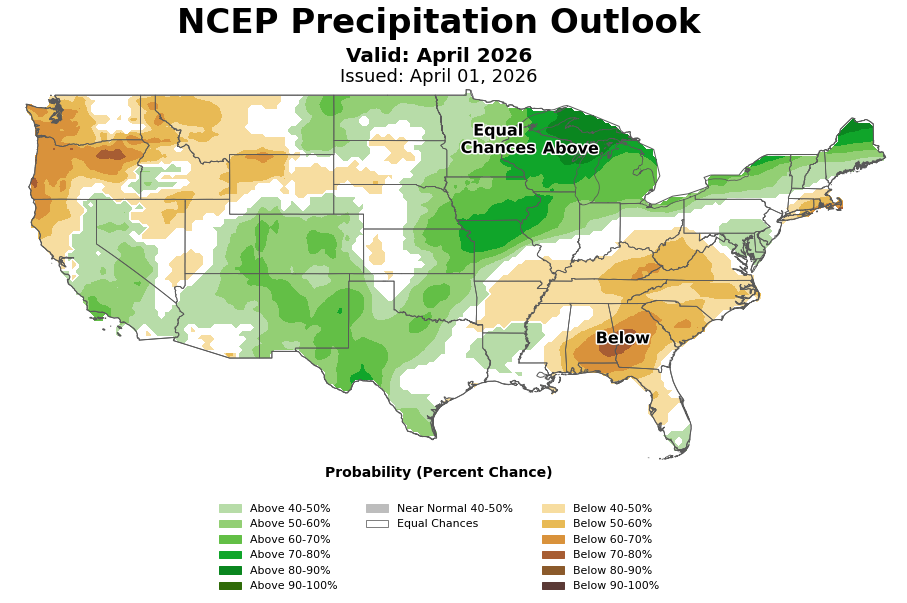

In [6]:
plot_model = 'NCEP'
plot_lead_month = 1
equal_chance_threshold = 0.40
issued_label = pd.Timestamp(init_date).strftime('%B %d, %Y')
plot_da = results[plot_model]['tercile_mean'].sel(lead_month=plot_lead_month)

fig, ax, masks, dominant, max_prob = plot_tercile_outlook(
    plot_da,
    model=plot_model,
    lead_month=plot_lead_month,
    issued_label=issued_label,
    equal_chance_threshold=equal_chance_threshold,
)
plt.show()

In [7]:
batch_png_out_dir = BASE_DIR / 'PNG' / init_date
batch_png_out_dir.mkdir(parents=True, exist_ok=True)

for batch_model in MODEL_NAMES:
    if batch_model not in results:
        print(f'Skip: {batch_model} not in results')
        continue

    available_leads = [int(x) for x in results[batch_model]['tercile_mean'].lead_month.values]
    for batch_lead_month in available_leads:
        batch_da = results[batch_model]['tercile_mean'].sel(lead_month=batch_lead_month)
        batch_issued_label = pd.Timestamp(init_date).strftime('%B %d, %Y')

        fig, ax, masks, dominant, max_prob = plot_tercile_outlook(
            batch_da,
            model=batch_model,
            lead_month=batch_lead_month,
            issued_label=batch_issued_label,
            equal_chance_threshold=equal_chance_threshold,
        )

        valid_label = valid_label_from_plot_da(batch_da).replace(' ', '_')
        out_png = batch_png_out_dir / f'{batch_model}_lead{batch_lead_month}_{valid_label}_tercile_outlook.png'
        out_pdf = batch_png_out_dir / f'{batch_model}_lead{batch_lead_month}_{valid_label}_tercile_outlook.pdf'

        fig.savefig(out_png, dpi=300, bbox_inches='tight')
        # fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
        plt.close(fig)

        print(f'Saved: {out_png.name}')



/opt/anaconda3/lib/python3.9/site-packages/matplotlib/contour.py:1486: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/opt/anaconda3/lib/python3.9/site-packages/matplotlib/contour.py:1487: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())


Saved: ECMWF_lead1_April_2026_tercile_outlook.png


/opt/anaconda3/lib/python3.9/site-packages/matplotlib/contour.py:1486: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/opt/anaconda3/lib/python3.9/site-packages/matplotlib/contour.py:1487: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())


Saved: ECMWF_lead2_May_2026_tercile_outlook.png


/opt/anaconda3/lib/python3.9/site-packages/matplotlib/contour.py:1486: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/opt/anaconda3/lib/python3.9/site-packages/matplotlib/contour.py:1487: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())


...

Saved: NCEP_lead2_May_2026_tercile_outlook.png


/opt/anaconda3/lib/python3.9/site-packages/matplotlib/contour.py:1486: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/opt/anaconda3/lib/python3.9/site-packages/matplotlib/contour.py:1487: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())


Saved: NCEP_lead3_June_2026_tercile_outlook.png


/opt/anaconda3/lib/python3.9/site-packages/matplotlib/contour.py:1486: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/opt/anaconda3/lib/python3.9/site-packages/matplotlib/contour.py:1487: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())


Saved: NCEP_lead4_July_2026_tercile_outlook.png


In [8]:

WR_LABELS = {1: 'Pacific Trough',2: 'Pacific Ridge',3: 'Pacific Wave',4: 'Alaskan Trough',5: 'Alaskan Ridge',}
WR_COLORS = {1: '#2ab07f',2: '#f04b0b',3: '#8173ad',4: '#e3b332',5: '#b85d1c',}

In [9]:

def monthly_wt_probability(wt_probability, init_date, n_leads=N_LEADS):
    target_months = get_target_month_starts(init_date, n_leads=n_leads)
    lead_probs = []
    for lead_idx, target_month in enumerate(target_months, start=1):
        start = pd.Timestamp(target_month)
        end = start + pd.offsets.MonthEnd(0)
        prob = (wt_probability.sel(time=slice(start, end)).mean(dim=('ensemble', 'time')))
        prob = prob.expand_dims(lead_month=[lead_idx])
        prob = prob.assign_coords(target_time=('lead_month', [np.datetime64(start)]))
        lead_probs.append(prob)
    out = xr.concat(lead_probs, dim='lead_month')
    out.name = 'monthly_wt_probability'
    return out


def plot_all_model_wt_probability(results, init_date, model_names=MODEL_NAMES, n_leads=N_LEADS):
    fig, axes = plt.subplots(1, len(model_names),figsize=(5.0 * len(model_names), 6),sharey=True)

    if len(model_names) == 1:
        axes = [axes]

    for ax, model in zip(axes, model_names):
        wt_monthly = monthly_wt_probability(results[model]['wt_probability'],init_date,n_leads=n_leads)
        values = wt_monthly.transpose('lead_month', 'wt').values * 100.0
        leads = wt_monthly.lead_month.values
        bottom = np.zeros(len(leads))

        for wt in range(1, N_WT + 1):
            vals = values[:, wt - 1]
            ax.bar(leads,vals,bottom=bottom,color=WR_COLORS[wt],edgecolor='black',linewidth=1.0,label=WR_LABELS[wt])
            for x, y, b in zip(leads, vals, bottom):
                if y >= 3:
                    ax.text(x,b + y / 2,f'{y:.0f}',ha='center',va='center',color='white',fontsize=13,fontweight='bold')

            bottom += vals

        ax.set_title(model, fontsize=18, fontweight='bold')
        valid_times = pd.to_datetime(wt_monthly.target_time.values)
        xticklabels = [f"{t.year}-{t.month:02d}"for t in valid_times]
        ax.set_xticks(leads)
        ax.set_xticklabels(xticklabels, fontsize=12)
        ax.set_ylim(0, 100)
        ax.grid(axis='y', linestyle=':', alpha=0.5)
        ax.set_axisbelow(True)

    axes[0].set_ylabel('Weather Regime Probability (%)', fontsize=14)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(0.5, 0.93),ncol=5,fontsize=13,frameon=False)
    issued_label = pd.Timestamp(init_date).strftime('%B %d, %Y')
    fig.suptitle(f'Monthly Weather Regime Probability\nIssued: {issued_label}',fontsize=20,fontweight='bold',y=1.03)
    plt.tight_layout(rect=[0, 0, 1, 0.88])

    out_png = batch_png_out_dir / f'All_models_lead1-4_wt_probability_{init_date}.png'
    fig.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(f'Saved: {out_png.name}')

In [10]:
plot_all_model_wt_probability(results, init_date)

Saved: All_models_lead1-4_wt_probability_20260401.png
